In [102]:
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

In [ ]:
users = pd.read_excel('dannye-dlia-keisa-po-pa-cebbefc3-5b29-4f88-b6d4-3336c88d743f.xlsx', sheet_name='Пользователи')

In [ ]:
users.head()

In [ ]:
users.info()

In [ ]:
users.shape

In [ ]:
payments = pd.read_excel('dannye-dlia-keisa-po-pa-cebbefc3-5b29-4f88-b6d4-3336c88d743f.xlsx', sheet_name='Платежи')

In [ ]:
payments.head()

In [ ]:
payments.info()

In [ ]:
payments.shape

**Проверка качества данных**

In [14]:
users.isna().sum()

,0
user_id,0
group,1
age,0
city,1
device_type,0


In [15]:
payments.isna().sum()

,0
payment_id,0
user_id,1
group,0
step1_opened,0
step2_entered,405
step3_confirmed,942
step4_success,1139


In [16]:
users.duplicated().sum()

np.int64(0)

In [17]:
payments.duplicated().sum()

np.int64(0)

In [19]:
users['user_id'].duplicated().sum()

np.int64(0)

In [20]:
payments['payment_id'].duplicated().sum()

np.int64(0)

In [23]:
users['group'].value_counts(dropna=False)

,count
group,
A,752
B,751
NaN,1


In [24]:
users['age'].min()

-5

In [25]:
users['age'].max()

150

In [26]:
users[users['group'].isna()]

,user_id,group,age,city,device_type
1500,9001,NaN,25,Москва,ios


Стоит рассмотреть данного пользователя в таблице payments, там может быть группа

In [27]:
users[users['city'].isna()]

,user_id,group,age,city,device_type
1503,9004,A,30,NaN,android


Оставляю, город не используется в расчете общей конверсии

In [28]:
users[(users['age'] < 0) |  (users['age'] > 120)]

,user_id,group,age,city,device_type
1501,9002,A,-5,СПб,android
1502,9003,B,150,Регион,ios


Оставляю, возвраст заменю на пропуск, так как фактический возраст неизвестен, данные можно использовать в расчете

In [30]:
payments[payments['user_id'].isna()]

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
2660,99003,NaN,A,2024-04-12 09:15:00,NaT,NaT,NaT


Исключаю, так как невозможно определить пользователя и понять, были ли у него другие попытки

In [39]:
payments[payments['user_id'].isin(users[users['group'].isna()]['user_id'])]

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success


Исключаю пользователя со значением NaN в таблице users столбце group, так как в таблице payments нет попыток с user_id этого пользователя

In [40]:
users.dropna(subset='group', inplace=True)

In [41]:
payments.dropna(subset='user_id', inplace=True)

In [44]:
users.loc[(users['age'] < 0) | (users['age'] > 120), 'age'] = float('nan')

In [46]:
payments[~payments['user_id'].isin(users['user_id'])]

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success


In [49]:
merged = pd.merge(payments, users, on='user_id', how='left')
merged

,payment_id,user_id,group_x,step1_opened,step2_entered,step3_confirmed,step4_success,group_y,age,city,device_type
0,5001,1001.0,A,2024-04-16 06:06:00,2024-04-16 06:10:00,NaT,NaT,A,31.0,Москва,ios
1,5002,1002.0,A,2024-04-12 07:38:00,2024-04-12 07:41:00,NaT,NaT,A,31.0,Москва,ios
2,5003,1003.0,A,2024-04-26 20:03:00,2024-04-26 20:07:00,NaT,NaT,A,25.0,Москва,android
3,5004,1004.0,A,2024-04-09 16:02:00,NaT,NaT,NaT,A,20.0,Москва,ios
4,5005,1004.0,A,2024-04-04 03:46:00,2024-04-04 03:54:00,2024-04-04 03:57:00,2024-04-04 04:02:00,A,20.0,Москва,ios
...,...,...,...,...,...,...,...,...,...,...,...
2655,7656,2499.0,B,2024-04-24 20:54:00,2024-04-24 21:00:00,2024-04-24 21:03:00,2024-04-24 21:08:00,B,42.0,Москва,ios
2656,7657,2500.0,B,2024-04-11 07:01:00,2024-04-11 07:04:00,NaT,NaT,B,39.0,Москва,ios
2657,7658,9004.0,A,2024-04-05 16:14:00,2024-04-05 16:15:00,2024-04-05 16:18:00,2024-04-05 16:23:00,A,30.0,NaN,android
2658,99001,1005.0,A,2024-04-05 10:30:00,2024-04-05 10:33:00,2024-04-05 10:38:00,2024-04-05 10:39:00,A,34.0,Москва,ios


In [51]:
merged[merged['group_x'] != merged['group_y']]

,payment_id,user_id,group_x,step1_opened,step2_entered,step3_confirmed,step4_success,group_y,age,city,device_type
2659,99002,1010.0,B,2024-04-08 14:20:00,2024-04-08 14:23:00,2024-04-08 14:28:00,2024-04-08 14:29:00,A,26.0,Москва,android


In [52]:
merged[merged['user_id'] == 1010.0]

,payment_id,user_id,group_x,step1_opened,step2_entered,step3_confirmed,step4_success,group_y,age,city,device_type
14,5015,1010.0,A,2024-04-27 13:26:00,NaT,NaT,NaT,A,26.0,Москва,android
2659,99002,1010.0,B,2024-04-08 14:20:00,2024-04-08 14:23:00,2024-04-08 14:28:00,2024-04-08 14:29:00,A,26.0,Москва,android


Невозможно определить к какой группе относится пользователь 1010.0. Исключаю пользователя из-за противоречивости группы.

In [55]:
users = users[users['user_id'] != 1010.0]

In [53]:
payments = payments[payments['user_id'] != 1010.0]

In [54]:
merged = merged[merged['user_id'] != 1010.0]

In [60]:
merged[(merged['step2_entered'] < merged['step1_opened']) |
       (merged['step3_confirmed'] < merged['step2_entered']) |
       (merged['step4_success'] < merged['step3_confirmed'])]

,payment_id,user_id,group_x,step1_opened,step2_entered,step3_confirmed,step4_success,group_y,age,city,device_type


In [62]:
merged[((merged['step3_confirmed'].notna()) & (merged['step2_entered'].isna())) |
      ((merged['step4_success'].notna()) & merged['step3_confirmed'].isna())]

,payment_id,user_id,group_x,step1_opened,step2_entered,step3_confirmed,step4_success,group_y,age,city,device_type


In [64]:
merged[['step1_opened', 'step2_entered', 'step3_confirmed', 'step4_success']].agg(['min', 'max'])

,step1_opened,step2_entered,step3_confirmed,step4_success
min,2024-04-01 00:19:00,2024-04-01 00:23:00,2024-04-01 00:29:00,2024-04-01 00:33:00
max,2024-04-30 23:17:00,2024-04-30 23:20:00,2024-04-30 23:25:00,2024-04-30 23:30:00


Все даты находятся в пределе 1-30 апреля 2024 года

Ключевая метрика: CR = Количество пользователей успешно cовершивних оплату/Количество пользователей открывших форму

Количество пользователей открывших форму

Считаю по group_y так как данный стобец взят из таблицы users

In [78]:
opened_users = merged.groupby('group_y')['user_id'].nunique()

Количество пользователей совершивших успешную оплату

In [79]:
paid_users = merged[merged['step4_success'].notna()].groupby('group_y')['user_id'].nunique()

In [81]:
conversion = paid_users / opened_users
conversion

,user_id
group_y,
A,0.657333
B,0.804000


**Разница в процентный пунктах**

In [82]:
(conversion['B'] - conversion['A']) * 100

np.float64(14.666666666666671)

**Относительный прирост в процентах**

In [83]:
(conversion['B'] - conversion['A']) / conversion['A'] * 100

np.float64(22.312373225152136)

**Использую статистический тест хи-квадрат**

In [87]:
results = pd.DataFrame({'paid': paid_users, 'not_paid': opened_users - paid_users})
results

,paid,not_paid
group_y,,
A,493,257
B,603,147


In [88]:
chi2, p_value, dof, expected = chi2_contingency(results, correction=False)

In [89]:
print('Хи-квадрат:', chi2)
print('p-value:', p_value)
print('Ожидаемые количества:')
print(expected)

Хи-квадрат: 40.99064103490641
p-value: 1.529599386664282e-10
Ожидаемые количества:
[[548. 202.]
 [548. 202.]]


In [95]:
entered_users = merged[merged['step2_entered'].notna()].groupby('group_y')['user_id'].nunique()
entered_users

,user_id
group_y,
A,671
B,707


In [98]:
confirmed_users = merged[merged['step3_confirmed'].notna()].groupby('group_y')['user_id'].nunique()
confirmed_users

,user_id
group_y,
A,548
B,644


In [111]:
voronka = pd.DataFrame({'Открыли форму': opened_users,
                      'Ввели реквизиты' : entered_users,
                      'Подтвердили платеж' : confirmed_users,
                      'Успешная оплата': paid_users})
voronka

,Открыли форму,Ввели реквизиты,Подтвердили платеж,Успешная оплата
group_y,,,,
A,750,671,548,493
B,750,707,644,603


In [112]:
step_conversion = pd.DataFrame({'Открыли-Ввели' : entered_users / opened_users * 100,
                                'Ввели-Подтвердили' : confirmed_users / entered_users * 100,
                                'Подтвердили-Оплатили' : paid_users / confirmed_users * 100})
step_conversion

,Открыли-Ввели,Ввели-Подтвердили,Подтвердили-Оплатили
group_y,,,
A,89.466667,81.669151,89.963504
B,94.266667,91.089109,93.633540


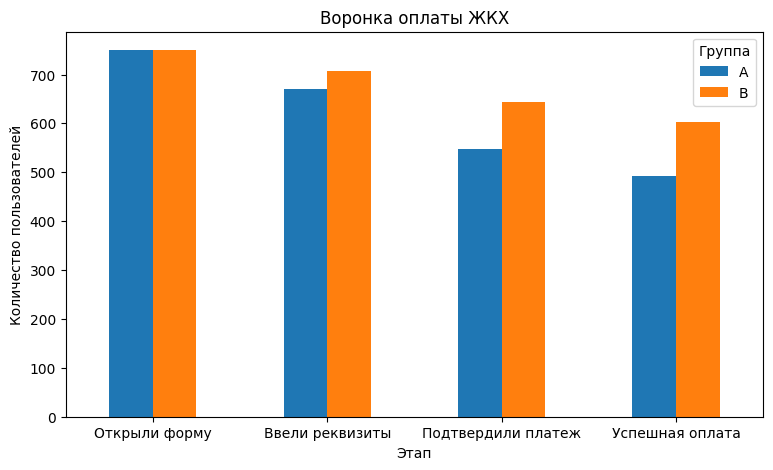

In [122]:
voronka.T.plot(kind='bar', figsize=(9, 5), rot = 0)
plt.title('Воронка оплаты ЖКХ')
plt.xlabel('Этап')
plt.ylabel('Количество пользователей')
plt.legend(title='Группа')
plt.savefig('voronka.png', dpi=200)
plt.show()

In [124]:
participants = merged.drop_duplicates(subset='user_id')

In [132]:
participants.groupby('group_y')['device_type'].value_counts(normalize=True)

group_y  device_type
A        android        0.541333
         ios            0.458667
B        ios            0.508000
         android        0.492000
Name: proportion, dtype: float64

In [136]:
participants.groupby('group_y')['city'].value_counts(normalize=True, dropna=False)

group_y  city  
A        Москва    0.382667
         Регион    0.357333
         СПб       0.258667
         NaN       0.001333
B        Москва    0.408000
         Регион    0.326667
         СПб       0.265333
Name: proportion, dtype: float64

In [137]:
participants.groupby('group_y')['age'].mean()

,age
group_y,
A,32.749333
B,32.654667


In [144]:
devices_all_users = merged.groupby(['group_y', 'device_type'])['user_id'].nunique()

In [145]:
devices_paid_users = merged[merged['step4_success'].notna()].groupby(['group_y', 'device_type'])['user_id'].nunique()

In [146]:
devices_paid_users / devices_all_users * 100

group_y  device_type
A        android        64.532020
         ios            67.151163
B        android        79.945799
         ios            80.839895
Name: user_id, dtype: float64